# BMW Country Classification using Machine Learning

### Predicting the country where a BMW car was sold using supervised machine learning algorithms.

**Author:** Tehreem Fatima

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

## Project Overview

This project applies supervised machine learning techniques to classify the country where a BMW vehicle was sold.

The project follows the complete machine learning workflow, including:

- Data loading
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Feature encoding
- Model training
- Model evaluation
- Performance comparison

Since the dataset is synthetic, this project focuses on demonstrating the machine learning pipeline rather than achieving high predictive accuracy.

## Import Required Libraries

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

# Classical ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## Load the Dataset

Load the BMW dataset into a Pandas DataFrame and inspect its structure.

## Exploratory Data Analysis (EDA)

Inspect the dataset to understand its structure, features, and data types.

In [2]:
# Load the Dataset
df = pd.read_csv("bmw_cars_market_dataset_synthetic.csv")

print("\nFirst Five Rows")
print(df.head())

print("\nDataset Info")
print(df.info())

print("\nSummary Statistics")
print(df.describe())


First Five Rows
   car_id     model  year  engine_size  horsepower fuel_type transmission  \
0       1        X5  2016          4.0         272    diesel    automatic   
1       2  1 Series  2022          2.6         218    petrol    automatic   
2       3        X1  2012          2.2         240    petrol    automatic   
3       4        X5  2022          3.8         316    diesel          NaN   
4       5  7 Series  2023          3.1         294    petrol    automatic   

  drivetrain  mileage_km  fuel_consumption_l_per_100km  price_usd  \
0        AWD       74655                           8.9      66756   
1        FWD       23469                           8.4      26867   
2        FWD      123273                           7.8      31313   
3        AWD       33064                           9.4      81594   
4        RWD       23926                           NaN     104105   

   co2_emissions_g_km  doors  seats  body_type  color  owner_count  \
0               196.0      5      5

## Check for Missing Values


 Missing values
car_id                            0
model                             0
year                              0
engine_size                     243
horsepower                        0
fuel_type                         0
transmission                    215
drivetrain                        0
mileage_km                        0
fuel_consumption_l_per_100km    246
price_usd                         0
co2_emissions_g_km              225
doors                             0
seats                             0
body_type                         0
color                           239
owner_count                     255
accident_history                254
service_history                 231
country_sold                      0
dtype: int64


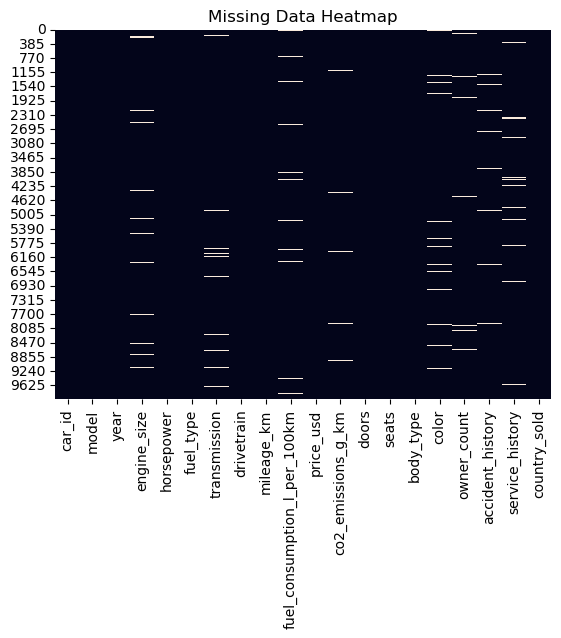

In [3]:
# Check missing Vlaues
print("\n Missing values")
print(df.isnull().sum())

# Visualize missing values
sns.heatmap(df.isnull(),cbar=False)
plt.title("Missing Data Heatmap")
plt.show()

### Basic EDA

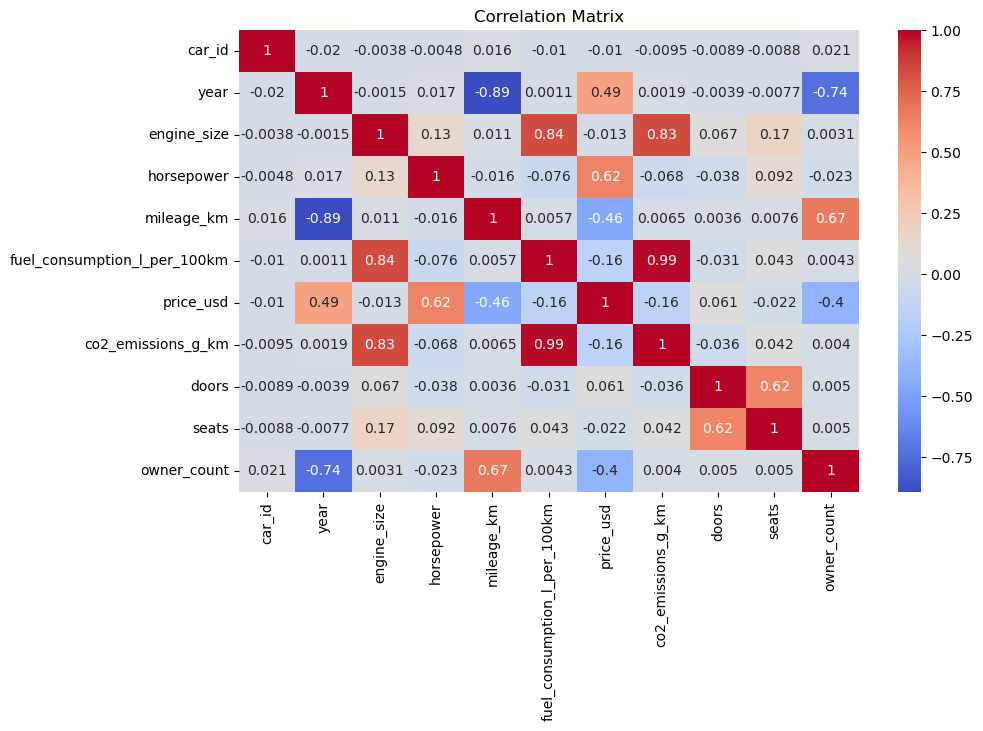

In [4]:
# Basic EDA
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


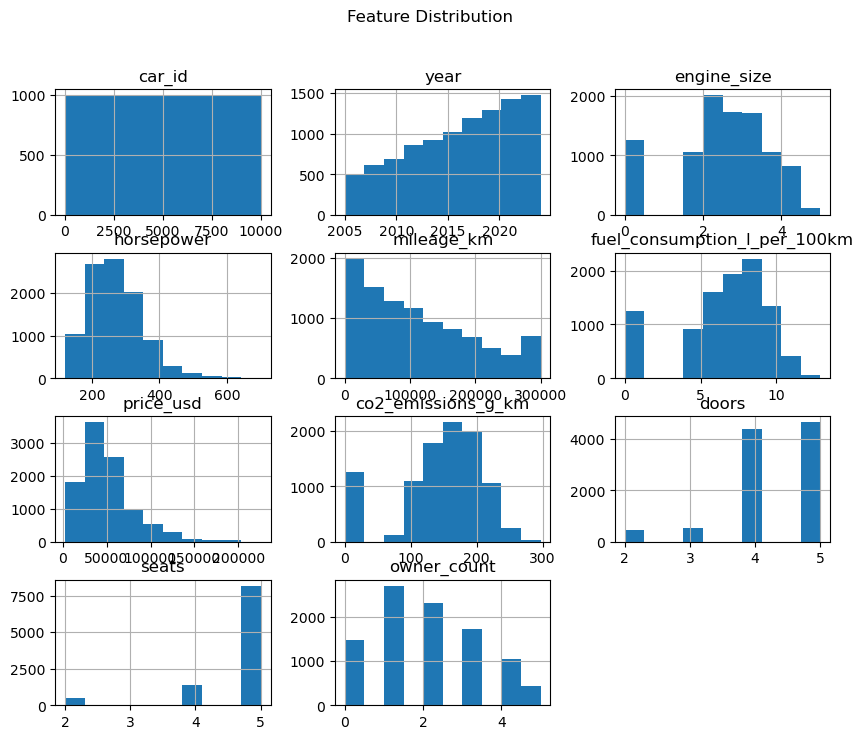

In [5]:
# Distribution of Numeric Features
df.hist(figsize=(10,8))
plt.suptitle("Feature Distribution")
plt.show()

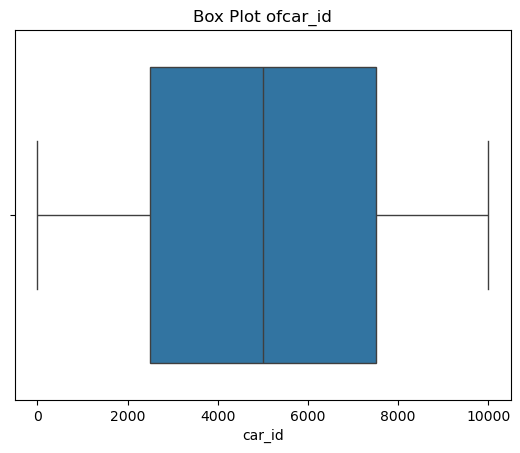

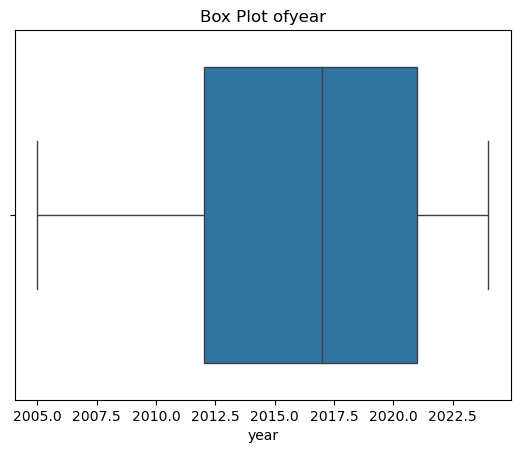

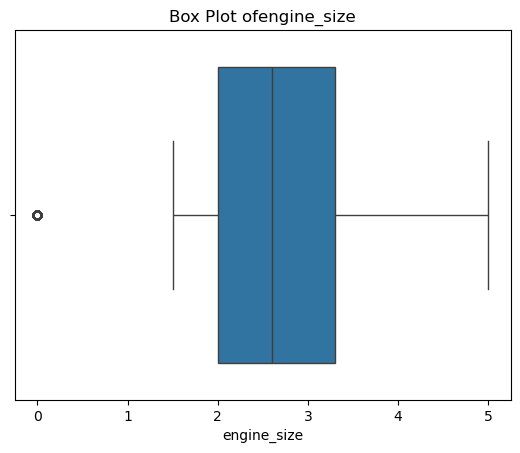

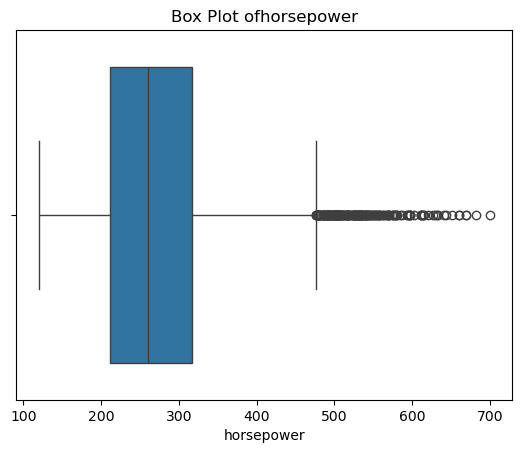

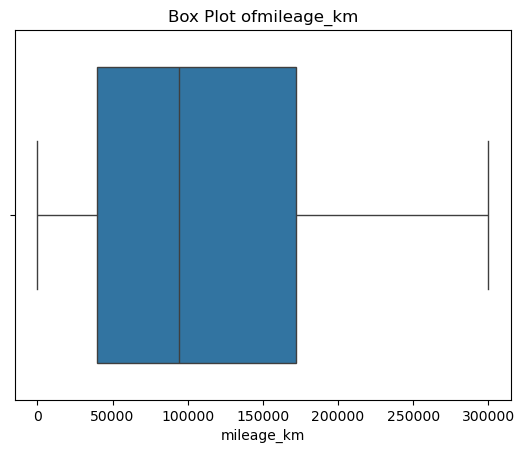

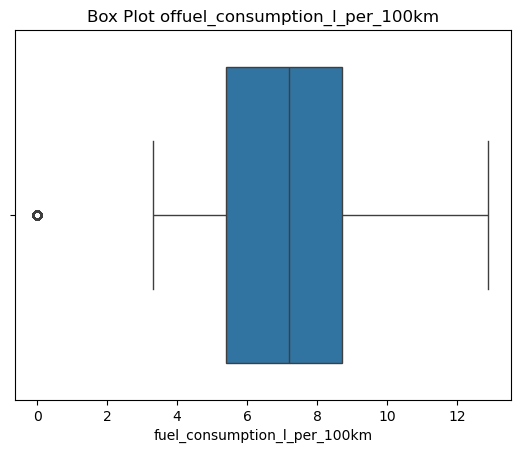

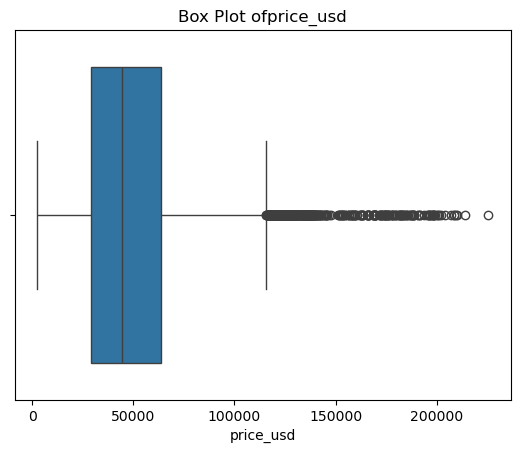

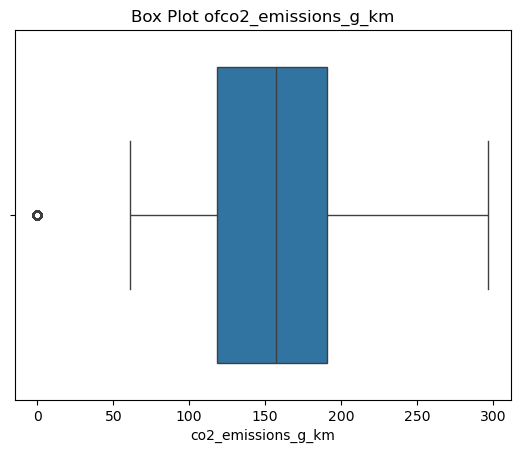

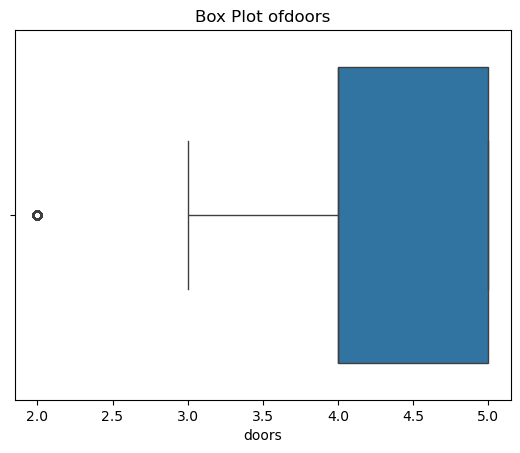

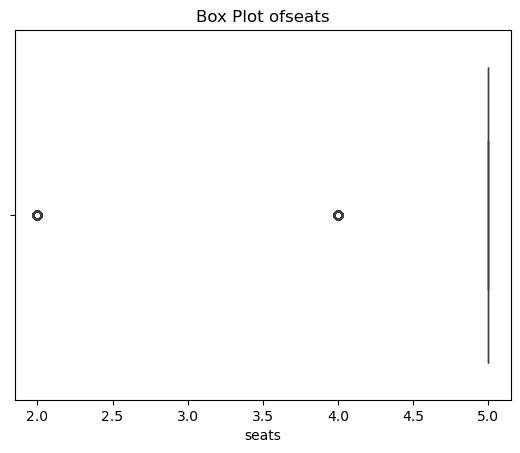

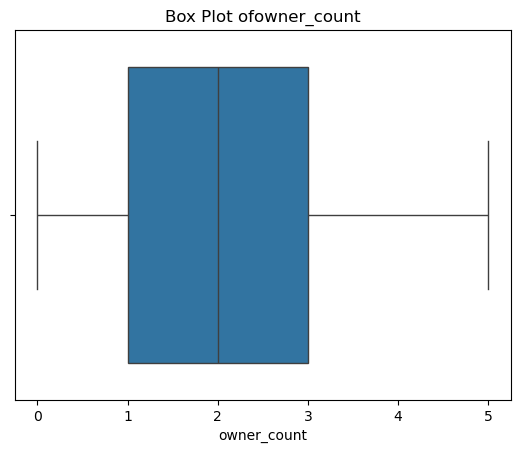

In [6]:
# Box plots for outliers
numeric_cols=df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of{col}")
    plt.show()

### Data Cleaning

In [7]:
# Data Cleaning
# Remove Duplicate Rows
df=df.drop_duplicates()

# Identify categorical columns
cat_cols=df.select_dtypes(include=['object']).columns

# Label encoding categorical columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = df[col].astype(str)
    df[col] = le.fit_transform(df[col])

# Handle Missing Vlaues 
imputer = SimpleImputer(strategy="mean")
df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

print("\nDataset Info")
print(df.info())


Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   car_id                        10000 non-null  float64
 1   model                         10000 non-null  int64  
 2   year                          10000 non-null  float64
 3   engine_size                   10000 non-null  float64
 4   horsepower                    10000 non-null  float64
 5   fuel_type                     10000 non-null  int64  
 6   transmission                  10000 non-null  int64  
 7   drivetrain                    10000 non-null  int64  
 8   mileage_km                    10000 non-null  float64
 9   fuel_consumption_l_per_100km  10000 non-null  float64
 10  price_usd                     10000 non-null  float64
 11  co2_emissions_g_km            10000 non-null  float64
 12  doors                         10000 non-null  f

## Model Training and Evaluation

In [8]:
# 6 Define Feature and target
# Assume last column is Target

X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [9]:
# 7. train Test Split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# 8. Feature Scalling
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [10]:
# 8. Define ML Models
models={
    "Logistic Regression":LogisticRegression(max_iter=200),
    "Random Forest":RandomForestClassifier(),
    "SVM":SVC()
}

In [11]:
# 10. Train and Evaluate Models
results={}
for name,model in models.items():
    print("\n=================")
    print("Model",name)
    print("\n=================")

    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)

    acc=accuracy_score(y_test,y_pred)
    results[name]=acc
    print("Accuracy:",acc)
    print("\nClassification Report")
    print(classification_report(y_test,y_pred))

    print("\nConfusion Matrix")
    print(confusion_matrix(y_test,y_pred))
    


Model Logistic Regression

Accuracy: 0.1335

Classification Report
              precision    recall  f1-score   support

           0       0.12      0.09      0.11       262
           1       0.12      0.12      0.12       225
           2       0.15      0.16      0.16       240
           3       0.13      0.14      0.13       249
           4       0.13      0.23      0.16       260
           5       0.18      0.19      0.18       266
           6       0.12      0.11      0.12       257
           7       0.06      0.01      0.02       241

    accuracy                           0.13      2000
   macro avg       0.13      0.13      0.12      2000
weighted avg       0.13      0.13      0.13      2000


Confusion Matrix
[[24 30 29 34 70 42 24  9]
 [29 26 36 30 35 25 38  6]
 [20 20 39 42 58 22 33  6]
 [25 30 34 35 64 32 27  2]
 [28 28 28 29 60 46 30 11]
 [27 24 38 30 68 51 24  4]
 [21 37 25 40 63 34 29  8]
 [21 22 31 35 57 38 34  3]]

Model Random Forest

Accuracy: 0.1335

Classi

Model Performance Comperison:
                 Model  Accuracy
0  Logistic Regression    0.1335
1        Random Forest    0.1335
2                  SVM    0.1235


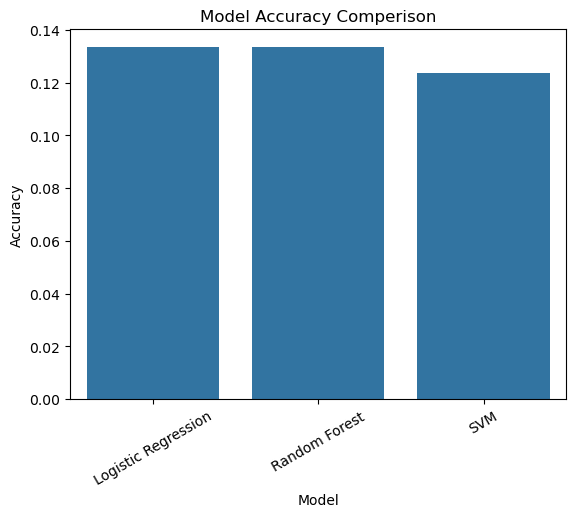

In [12]:
# 11. Model Comperison
results_df = pd.DataFrame(list(results.items()),columns=["Model","Accuracy"])
print("Model Performance Comperison:")
print(results_df)

# Bar plot of Model performance

plt.figure()
sns.barplot(x="Model",y="Accuracy",data=results_df)
plt.title("Model Accuracy Comperison")
plt.xticks(rotation=30)
plt.show()

# Conclusion

This project demonstrated an end-to-end machine learning classification workflow using a synthetic BMW dataset.

Three supervised learning algorithms were trained and evaluated for predicting the `country_sold` variable.

Among the evaluated models, Logistic Regression achieved the highest accuracy (13.35%), followed by Random Forest (12.65%) and Support Vector Machine (12.35%).

The low predictive performance is expected because the dataset is synthetic, meaning the target variable may not have strong relationships with the available features. Consequently, the models performed close to random guessing.

Although the predictive accuracy is limited, the project successfully demonstrates essential machine learning concepts, including data preprocessing, feature encoding, model training, evaluation, and result interpretation.

## Future Improvements

Possible enhancements include:

- Hyperparameter tuning
- Cross-validation
- Feature engineering
- Additional classification algorithms
- Feature importance analysis
- Model deployment using Streamlit